# Lab 1: Deep Learning Image Classification with PyTorch

## 1. Introduction

Welcome to the first hands-on lab of our Generative AI Masterclass! In this session, we'll build an image classifier using PyTorch to identify different types of flowers from the Oxford Flowers 102 dataset. This lab will establish fundamental skills that will serve as building blocks for more advanced generative AI applications in later modules.

### Learning Objectives
- Set up a PyTorch development environment
- Understand neural network architecture components
- Load and preprocess image data
- Build, train, and evaluate a deep learning classifier
- Implement custom neural network components from scratch
- Interpret model performance and results

### Visual Overview
```
┌─────────────┐     ┌─────────────┐     ┌─────────────┐     ┌─────────────┐
│ Input Image │ → │ Preprocess  │ → │ Neural Net  │ → │ Prediction  │
└─────────────┘     └─────────────┘     └─────────────┘     └─────────────┘
```

## 2. Environment Setup

### Prerequisites
- Anaconda or Miniconda installed on your system
- Basic familiarity with terminal/command line
- Basic Python knowledge

### Verification Checklist
- Terminal shows (lab_1) in prompt
- `python --version` outputs Python 3.9.x
- 'lab_1' appears in Jupyter's kernel list

## 3. Dependencies Installation

Let's install the required Python packages for this lab:

In [19]:
# Install required packages
!uv add --quiet torch torchvision matplotlib scikit-learn pandas seaborn tqdm ipywidgets "numpy<2"

In [20]:
# Import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import scipy.io
import random
import os
from PIL import Image
from tqdm.notebook import tqdm

# Check for GPU availability
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# Set random seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        
set_seed()

Using device: cpu


## 4. Dataset Preparation

### 4.1 Oxford Flowers 102 Dataset

We'll use the Oxford Flowers 102 dataset, which contains 102 categories of flowers common in the UK. Each class has between 40 and 258 images.

In [21]:
# Load flower names mapping
df = pd.read_csv('oxford_flower_102_name.csv')
flower_mapper = dict(zip(df['Index'], df['Name']))
label_list = list(flower_mapper.values())

print(f"Total flower categories: {len(label_list)}")
print(f"Sample categories: {label_list[:5]}...")

Total flower categories: 102
Sample categories: ['pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold']...


### 4.2 Data Loading and Preprocessing

In [22]:
# Define data transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),  # Resize to standard input size
        transforms.RandomHorizontalFlip(),  # Data augmentation
        transforms.RandomRotation(15),  # Data augmentation
        #transforms.ColorJitter(brightness=0.1, contrast=0.1),  # Data augmentation
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
}

# Basic transforms (for visualization)
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Load the datasets
train_data = torchvision.datasets.Flowers102(
    root='./data', 
    split="train", 
    transform=data_transforms['train'], 
    download=True
)

test_data = torchvision.datasets.Flowers102(
    root='./data', 
    split="test", 
    transform=data_transforms['test']
)

# Create data loaders
batch_size = 32
loaders = {
    'train': DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2),
    'test': DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2)
}

print(f"Training set size: {len(train_data)}")
print(f"Test set size: {len(test_data)}")

Training set size: 1020
Test set size: 6149


### 4.3 Data Exploration

Let's visualize some sample images from our dataset:

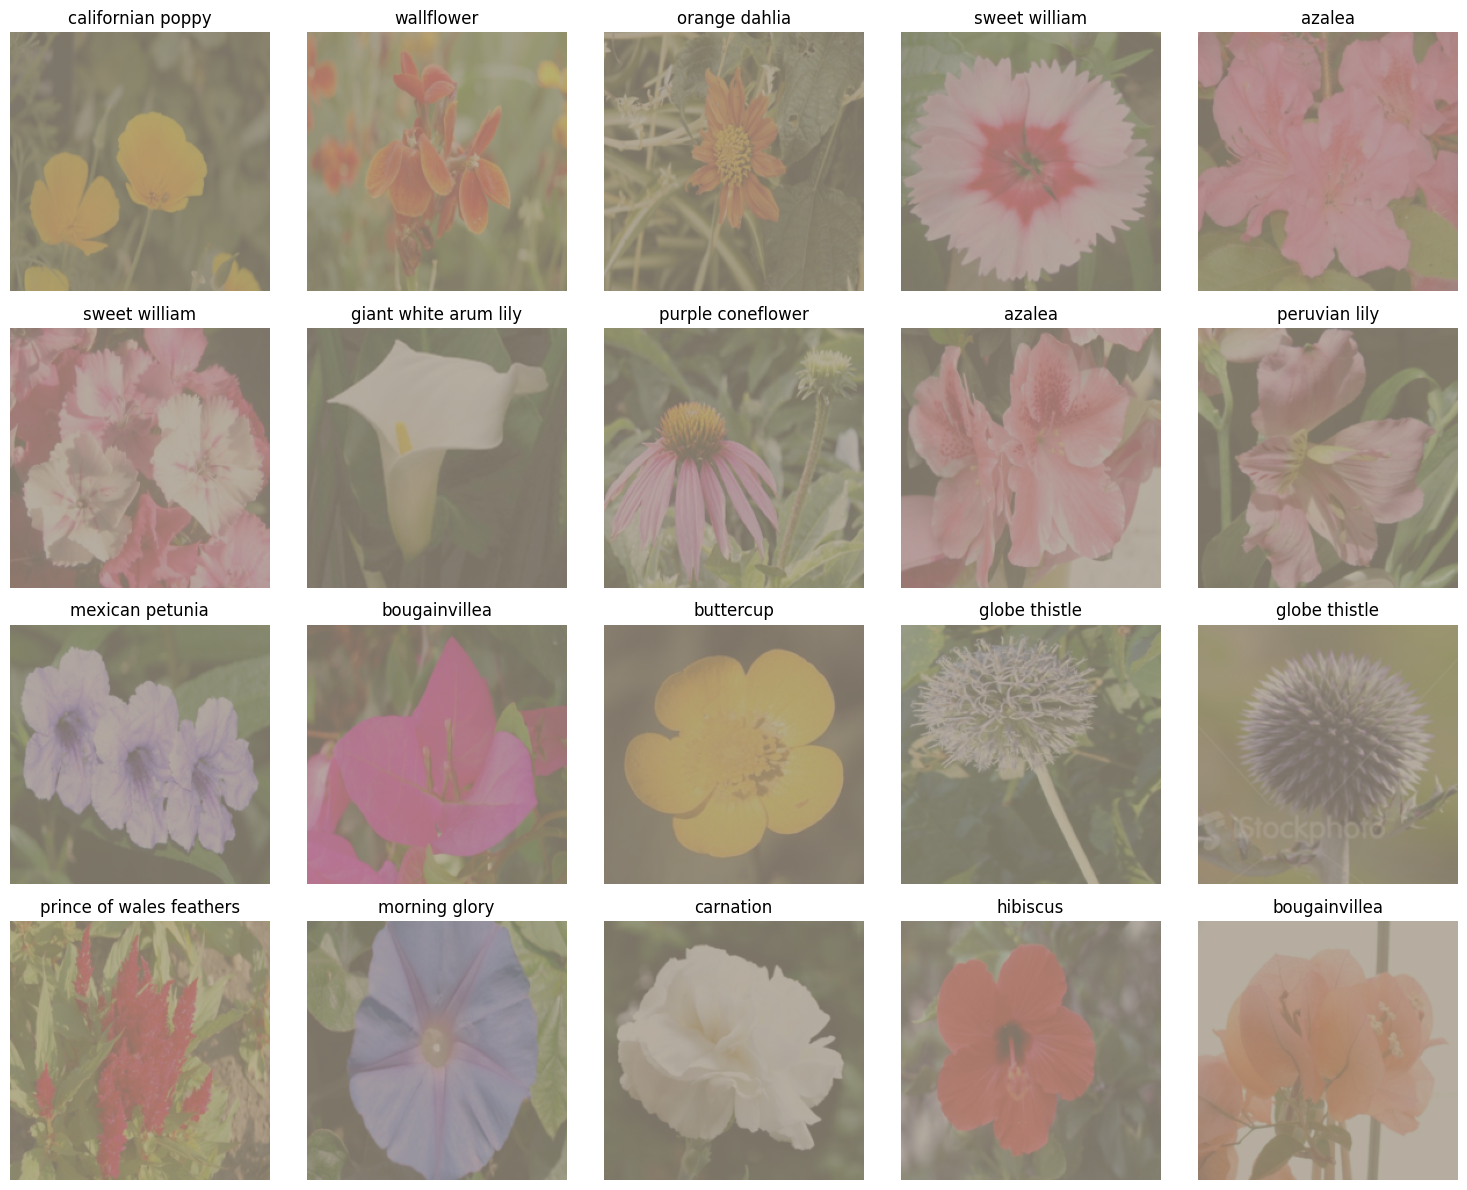

In [23]:
def imshow(img, title=None):
    """Display an image tensor"""
    # Unnormalize
    img = img.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

# Visualize sample images
plt.figure(figsize=(15, 12))
cols, rows = 5, 4
for i in range(cols * rows):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    
    # Convert to display format
    plt.subplot(rows, cols, i + 1)
    
    # Get the original image without normalization for better visualization
    original_img = torchvision.datasets.Flowers102(
        root='./data', split="train", transform=basic_transform
    )[sample_idx][0]
    
    imshow(original_img, title=flower_mapper[label])

plt.tight_layout()
plt.show()

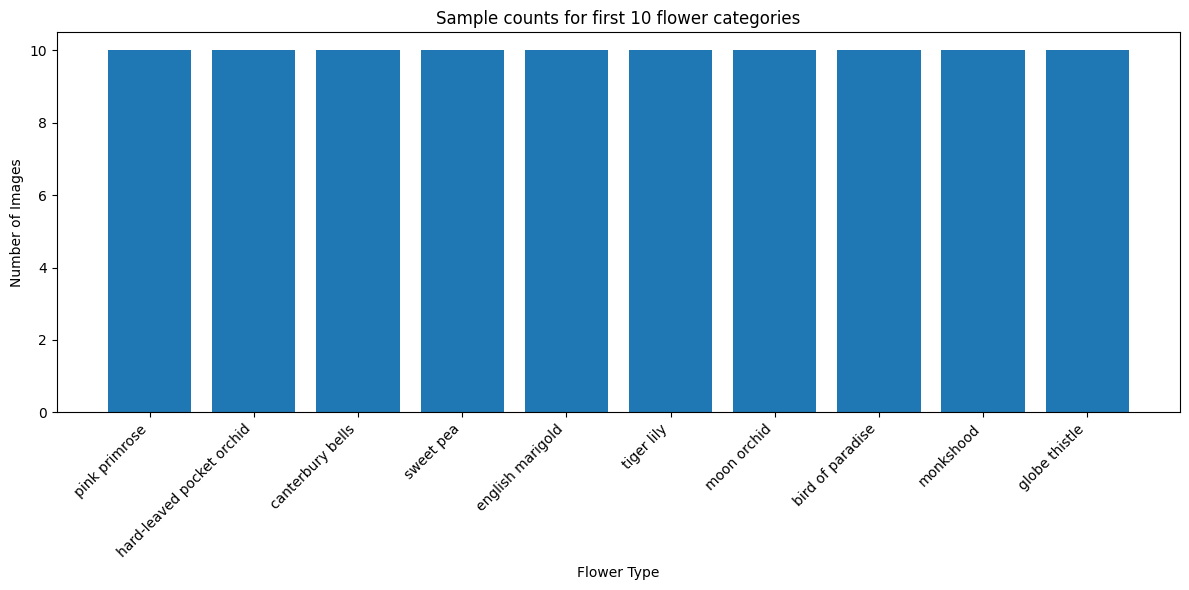

Average images per class: 10.0
Min images per class: 10
Max images per class: 10


In [24]:
# Let's analyze class distribution
class_counts = {}
for _, label in train_data:
    class_name = flower_mapper[label]
    class_counts[class_name] = class_counts.get(class_name, 0) + 1

plt.figure(figsize=(12, 6))
plt.bar(list(class_counts.keys())[:10], [class_counts[k] for k in list(class_counts.keys())[:10]])
plt.xticks(rotation=45, ha='right')
plt.title('Sample counts for first 10 flower categories')
plt.xlabel('Flower Type')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

print(f"Average images per class: {np.mean(list(class_counts.values())):.1f}")
print(f"Min images per class: {np.min(list(class_counts.values()))}")
print(f"Max images per class: {np.max(list(class_counts.values()))}")

## 5. Custom Neural Network Implementation

One of the unique aspects of this lab is that we'll implement some neural network components from scratch to better understand how they work.

### 5.1 Linear Layer Implementation

In [26]:
class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, std: float = 0.1):
        """
        Initialize a linear layer with random weights.

        Args:
            in_features: Number of input features
            out_features: Number of output features
            std: Standard deviation for weight initialization
        """
        super(Linear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features

        # Initialize weights using Kaiming initialization (scaled by sqrt of fan-in)
        self.weight = nn.Parameter(torch.randn(out_features, in_features) / np.sqrt(in_features))
        self.bias = nn.Parameter(torch.zeros(out_features))
        
        self.to(device=device)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Perform linear transformation by multiplying the input tensor
        with the weight matrix, and adding the bias.
        """
        return torch.matmul(x, self.weight.t()) + self.bias

    def __repr__(self) -> str:
        return f'Linear(in_features={self.in_features}, out_features={self.out_features}, bias={self.bias is not None})'

### 5.2 Activation Functions

In [27]:
class ReLU(nn.Module):
    """
    Rectified Linear Unit (ReLU) activation function.
    f(x) = max(0, x)
    """
    @staticmethod
    def forward(x: torch.Tensor) -> torch.Tensor:
        return torch.clip(x, 0.)
        # Alternative implementation: return torch.max(torch.zeros_like(x), x)

### 5.3 Regularization Layers

In [28]:
class Dropout(nn.Module):
    """
    Applies dropout regularization technique to the input tensor.

    During training, randomly zeroes some elements with probability p,
    then scales the remaining elements by 1/(1-p).
    """
    def __init__(self, p=0.5):
        super(Dropout, self).__init__()
        self.p = p  # Probability of zeroing an element

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.training:
            # Create random mask (1 with prob 1-p, 0 with prob p)
            mask = (torch.rand(x.shape) > self.p).float().to(x.device)
            # Scale by 1/(1-p) to maintain expected sum
            return x * mask / (1 - self.p)
        return x  # In evaluation mode, return input unchanged
        
    def __repr__(self) -> str:
        return f'Dropout(p={self.p})'

### 5.4 Utility Layers

In [29]:
class Flatten(nn.Module):
    """
    Reshape the input tensor by flattening all dimensions except the batch dimension.
    """
    @staticmethod
    def forward(x: torch.Tensor) -> torch.Tensor:
        return x.reshape(x.size(0), -1)
        
    def __repr__(self) -> str:
        return 'Flatten()'

### 5.5 Sequential Container

In [30]:
class Sequential(nn.Module):
    """
    Sequential container for stacking multiple modules,
    passing the output of one module as input to the next.
    """
    def __init__(self, *layers):
        super(Sequential, self).__init__()
        self.layers = nn.ModuleList(layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x)
        return x

    def __repr__(self) -> str:
        layer_str = '\n'.join([f'  ({i}): {layer}' for i, layer in enumerate(self.layers)])
        return f'{self.__class__.__name__}(\n{layer_str}\n)'

## 6. Model Architecture

Now we'll build our flower classifier using the components we've created.

In [32]:
class FlowerClassifier(nn.Module):
    """
    Neural network classifier for the Oxford Flowers 102 dataset.
    """
    def __init__(self, num_classes=102):
        super(FlowerClassifier, self).__init__()
        self.labels = label_list
        
        # Calculate input size based on image dimensions
        # For 224x224 RGB images: 3 * 224 * 224 = 150,528
        input_size = 3 * 224 * 224
        
        # Main network architecture
        self.main = Sequential(
            Flatten(),  # Flatten input image
            Linear(in_features=input_size, out_features=1024),
            ReLU(),
            Dropout(0.3),  # Apply dropout for regularization
            Linear(in_features=1024, out_features=512),
            ReLU(),
            Dropout(0.3),
            Linear(in_features=512, out_features=256),
            ReLU(),
            Linear(in_features=256, out_features=num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass through the network"""
        return self.main(x)
    
    def predictions(self, x):
        """Generate predictions with probabilities for each class"""
        with torch.no_grad():
            logits = self.forward(x)
            probs = torch.nn.functional.softmax(logits, dim=1)
            
            # For a single image
            if x.dim() == 3:
                x = x.unsqueeze(0)  # Add batch dimension
                predictions = dict(zip(self.labels, probs.cpu().detach().numpy().flatten()))
            # For a batch of images
            else:
                # Return prediction for each image in batch
                predictions = [dict(zip(self.labels, p)) for p in probs.cpu().detach().numpy()]
                
        return predictions

# Initialize the model
model = FlowerClassifier().to(device)
print(model)

FlowerClassifier(
  (main): Sequential(
    (0): Flatten()
    (1): Linear(in_features=150528, out_features=1024, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3)
    (7): Linear(in_features=512, out_features=256, bias=True)
    (8): ReLU()
    (9): Linear(in_features=256, out_features=102, bias=True)
  )
)


## 7. Optimizer Implementation

Let's implement a simple gradient descent optimizer:

In [33]:
class Optimizer:
    """
    Simple gradient descent optimizer to update model parameters during training.
    """
    def __init__(self, params, lr=0.01, momentum=0.9):
        self.params = list(params)
        self.lr = lr
        self.momentum = momentum
        self.velocity = [torch.zeros_like(p.data) for p in self.params]

    def step(self):
        """Perform one optimization step"""
        for i, p in enumerate(self.params):
            if p.grad is not None:
                # Apply momentum update
                self.velocity[i] = self.momentum * self.velocity[i] - self.lr * p.grad.data
                p.data += self.velocity[i]

    def zero_grad(self):
        """Reset gradients to zero"""
        for p in self.params:
            if p.grad is not None:
                p.grad.data.zero_()

## 8. Training Configuration

In [34]:
from dataclasses import dataclass

@dataclass
class LearnerConfig:
    """Configuration for model training"""
    model: nn.Module
    criterion: nn.Module  # Loss function
    epochs: int
    batch_size: int
    lr: float
    device: str
    early_stopping_patience: int = 5

# Create configuration
config = LearnerConfig(
    model=model,
    criterion=nn.CrossEntropyLoss(),
    epochs=1,
    batch_size=32,
    lr=0.001,
    device=device,
)

## 9. Training and Evaluation Pipeline

In [35]:
class Learner:
    """
    Training and evaluation pipeline for deep learning models.
    """
    def __init__(self, config, loaders):
        self.model = config.model
        self.loaders = loaders
        self.optimizer = Optimizer(self.model.parameters(), config.lr)
        self.criterion = config.criterion
        self.epochs = config.epochs
        self.device = config.device
        self.labels = label_list
        self.patience = config.early_stopping_patience
        self.history = {'train_loss': [], 'val_loss': [], 'accuracy': []}
        self.best_accuracy = 0
        self.model.to(self.device)

    def train_epoch(self):
        """Train the model for one epoch"""
        self.model.train()  # Set model to training mode
        epoch_loss = 0.0
        progress_bar = tqdm(self.loaders["train"], desc="Training")
        
        for x, y in progress_bar:
            x, y = x.to(self.device), y.to(self.device)
            batch_size = x.size(0)

            # Zero out gradients
            self.optimizer.zero_grad()
   
            # Forward pass, loss calculation, and backpropagation
            output = self.model(x)
            loss = self.criterion(output, y)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item() * batch_size
            progress_bar.set_postfix({'loss': loss.item()})

        train_loss = epoch_loss / len(self.loaders['train'].dataset)
        return train_loss
    
    def valid_loss(self):
        """Calculate the validation loss"""
        self.model.eval()  # Set model to evaluation mode
        val_loss = 0.0
        with torch.no_grad():
            for x, y in tqdm(self.loaders["test"], desc="Validation"):
                x, y = x.to(self.device), y.to(self.device)
                output = self.model(x)
                val_loss += self.criterion(output, y).item() * y.size(0)
        val_loss /= len(self.loaders["test"].dataset)
        return val_loss

    def batch_accuracy(self, x, y):
        """Calculate accuracy for a batch"""
        with torch.no_grad():
            _, preds = torch.max(x.data, 1)
            return (preds == y).sum().item() / x.size(0)

    def validate_epoch(self):
        """Evaluate model accuracy on test dataset"""
        self.model.eval()
        with torch.no_grad():
            accs = []
            for x, y in tqdm(self.loaders["test"], desc="Computing accuracy"):
                x, y = x.to(self.device), y.to(self.device)
                outputs = self.model(x)
                acc = self.batch_accuracy(outputs, y)
                accs.append(acc)
        return sum(accs) / len(accs)
            
    def fit(self, log_interval=1):
        """Train the model for the specified number of epochs"""
        print('Epoch\tTrain Loss\tVal Loss\tAccuracy')
        print('-----\t----------\t--------\t--------')
        
        no_improve_count = 0
        
        for epoch in range(self.epochs):
            train_loss = self.train_epoch()
            val_loss = self.valid_loss()
            accuracy = self.validate_epoch()
            
            # Store metrics
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['accuracy'].append(accuracy)
            
            if epoch % log_interval == 0:
                print(f'{epoch+1}\t{train_loss:.6f}\t{val_loss:.6f}\t{accuracy:.6f}')
            
            # Early stopping check
            if accuracy > self.best_accuracy:
                self.best_accuracy = accuracy
                no_improve_count = 0
                # Save best model
                torch.save(self.model.state_dict(), 'best_flower_model.pt')
            else:
                no_improve_count += 1
                
            if no_improve_count >= self.patience:
                print(f'Early stopping at epoch {epoch+1}. No improvement for {self.patience} epochs.')
                break
                
        print(f'\nTraining complete! Best accuracy: {self.best_accuracy:.4f}')
        
        # Load best model for evaluation
        self.model.load_state_dict(torch.load('best_flower_model.pt'))
        
        # Evaluate final model
        metrics = self.evaluate()
        return self.history, metrics
    
    def export(self, path):
        """Save the trained model"""
        torch.save(self.model, path)
                            
    def evaluate(self):
        """Evaluate model performance with detailed metrics"""
        self.model.eval()
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for x, y in tqdm(self.loaders["test"], desc="Evaluating"):
                x, y = x.to(self.device), y.to(self.device)
                outputs = self.model(x)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(y.cpu().numpy())

        # Calculate metrics
        accuracy = np.mean(np.array(all_preds) == np.array(all_targets))
        class_precision = precision_score(all_targets, all_preds, average=None, zero_division=0)
        class_recall = recall_score(all_targets, all_preds, average=None, zero_division=0)
        class_f1 = f1_score(all_targets, all_preds, average=None, zero_division=0)
        
        overall_precision = precision_score(all_targets, all_preds, average='weighted', zero_division=0)
        overall_recall = recall_score(all_targets, all_preds, average='weighted', zero_division=0)
        overall_f1 = f1_score(all_targets, all_preds, average='weighted', zero_division=0)

        class_metrics = {label: {"precision": prec, "recall": rec, "f1": f1}
                   for label, prec, rec, f1 in zip(self.labels, class_precision, class_recall, class_f1)}
        
        overall_metrics = {
            "accuracy": accuracy,
            "precision": overall_precision,
            "recall": overall_recall,
            "f1": overall_f1
        }
        
        # Generate confusion matrix
        conf_matrix = confusion_matrix(all_targets, all_preds)
        
        return {
            "class_metrics": class_metrics,
            "overall_metrics": overall_metrics,
            "confusion_matrix": conf_matrix
        }
    
    def plot_training_history(self):
        """Plot training metrics over time"""
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(self.history['train_loss'], label='Train Loss')
        plt.plot(self.history['val_loss'], label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.title('Training and Validation Loss')
        
        plt.subplot(1, 2, 2)
        plt.plot(self.history['accuracy'], label='Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Model Accuracy')
        
        plt.tight_layout()
        plt.show()
    
    def plot_confusion_matrix(self, metrics, top_n=10):
        """Plot confusion matrix for top N most confused classes"""
        cm = metrics["confusion_matrix"]
        
        # Find the most confused classes
        np.fill_diagonal(cm, 0)  # Zero out the diagonal to find misclassifications
        confused_pairs = []
        
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                if cm[i, j] > 0:
                    confused_pairs.append((i, j, cm[i, j]))
        
        # Sort by number of confusions
        confused_pairs.sort(key=lambda x: x[2], reverse=True)
        
        # Take top N
        top_pairs = confused_pairs[:top_n]
        
        # Create a smaller confusion matrix with just these classes
        classes = list(set([i for i, j, _ in top_pairs] + [j for i, j, _ in top_pairs]))
        classes.sort()
        
        labels = [self.labels[i] for i in classes]
        sub_cm = cm[np.ix_(classes, classes)]
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(sub_cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
        plt.title(f'Confusion Matrix for Top {len(classes)} Most Confused Classes')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

## 10. Model Training

Now let's train our model:

Epoch	Train Loss	Val Loss	Accuracy
-----	----------	--------	--------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/193 [00:00<?, ?it/s]

Computing accuracy:   0%|          | 0/193 [00:00<?, ?it/s]

1	5.022753	4.575424	0.033517

Training complete! Best accuracy: 0.0335


Evaluating:   0%|          | 0/193 [00:00<?, ?it/s]

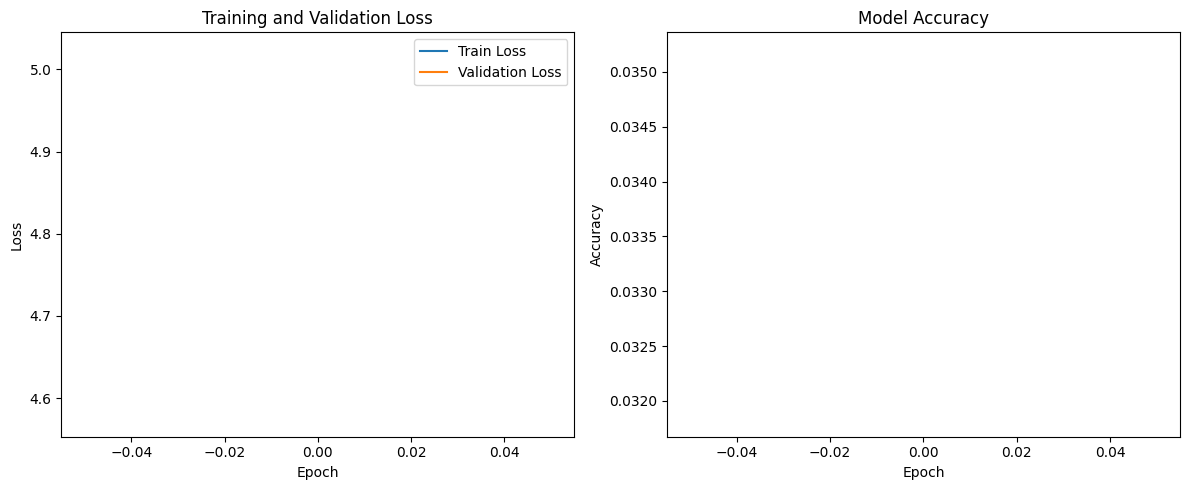


Overall Model Performance:
-------------------------
Accuracy: 0.0337
Precision: 0.0290
Recall: 0.0337
F1: 0.0215

Class-specific Performance (Top 10 classes):
------------------------------------------
Label                      Precision   Recall      F1-score
-----------------------------------------------------------
poinsettia                 0.2049      0.3425      0.2564
sunflower                  0.2632      0.1220      0.1667
gazania                    0.0919      0.2931      0.1399
colt's foot                0.1429      0.0896      0.1101
cyclamen                   0.0824      0.1119      0.0949
hard-leaved pocket orchid  0.0667      0.1250      0.0870
buttercup                  0.0531      0.2353      0.0866
desert-rose                0.1333      0.0465      0.0690
corn poppy                 0.0372      0.3810      0.0678
grape hyacinth             0.1111      0.0476      0.0667


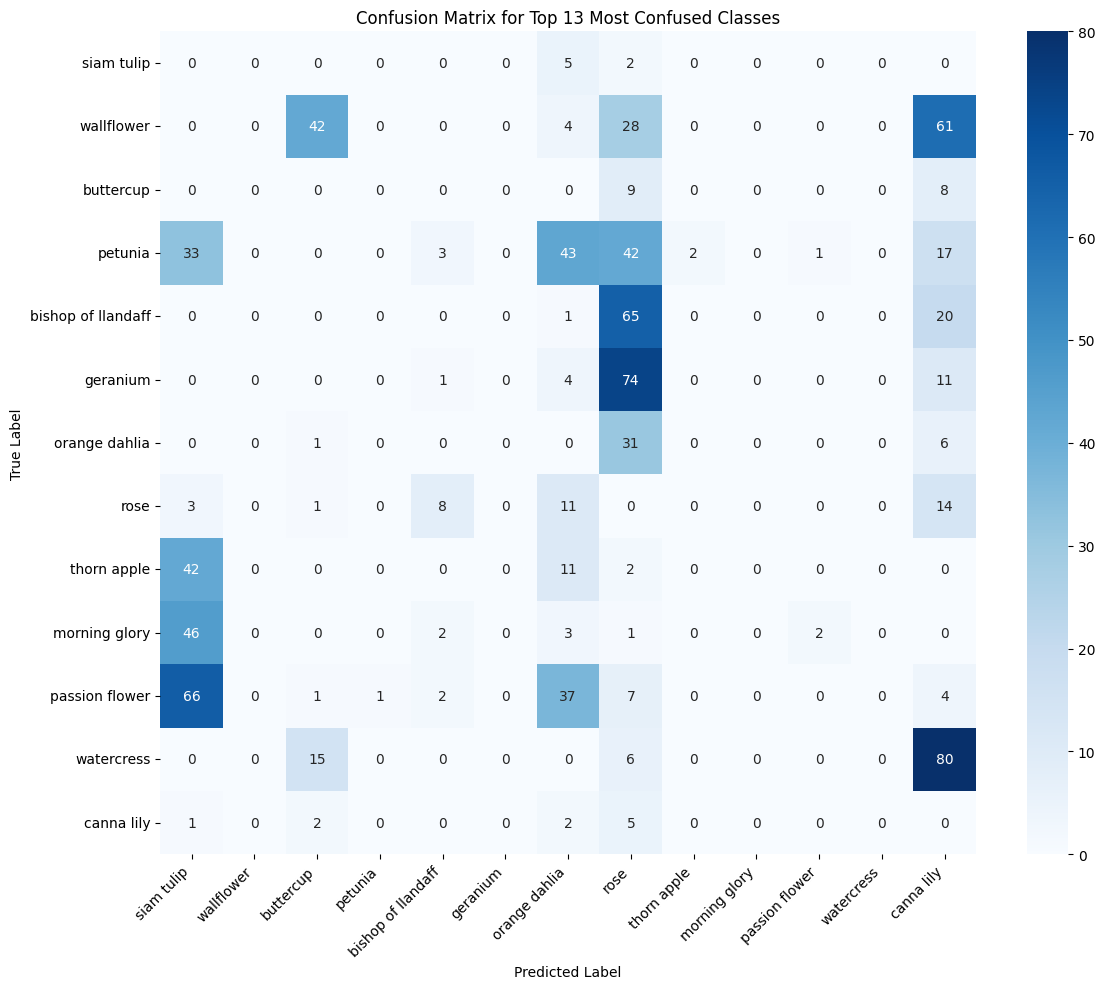

In [36]:
# Create learner and train the model
learner = Learner(config, loaders)
history, metrics = learner.fit()

# Plot training history
learner.plot_training_history()

# Export the trained model
learner.export('flower_classifier_final.pt')


## 11. Performance Evaluation
# Print overall metrics
print("\nOverall Model Performance:")
print("-------------------------")
for metric, value in metrics["overall_metrics"].items():
    print(f"{metric.capitalize()}: {value:.4f}")

# Print class metrics
print("\nClass-specific Performance (Top 10 classes):")
print("------------------------------------------")

# Determine the maximum label length for padding
max_label_len = max(len(label) for label in label_list)

header = "Label".ljust(max_label_len + 2) + "Precision".ljust(12) + "Recall".ljust(12) + "F1-score"
print(header)
print("-" * len(header))

# Sort by F1 score
sorted_metrics = sorted(
    [(label, metrics["class_metrics"][label]) for label in label_list],
    key=lambda x: x[1]['f1'],
    reverse=True
)

# Print metrics for top 10 classes
for label, metric in sorted_metrics[:10]:
    row = label.ljust(max_label_len + 2) + \
        f"{metric['precision']:.4f}".ljust(12) + \
        f"{metric['recall']:.4f}".ljust(12) + \
        f"{metric['f1']:.4f}"
    print(row)

# Plot confusion matrix
learner.plot_confusion_matrix(metrics)

## 11. Model Inference

Let's use our trained model to make predictions on some test images:

Looking for images in: data/flowers-102/jpg
Found: data/flowers-102/jpg/image_00781.jpg
Found: data/flowers-102/jpg/image_00782.jpg
Found: data/flowers-102/jpg/image_00783.jpg
Found: data/flowers-102/jpg/image_00784.jpg
Found: data/flowers-102/jpg/image_00785.jpg
Found: data/flowers-102/jpg/image_00786.jpg


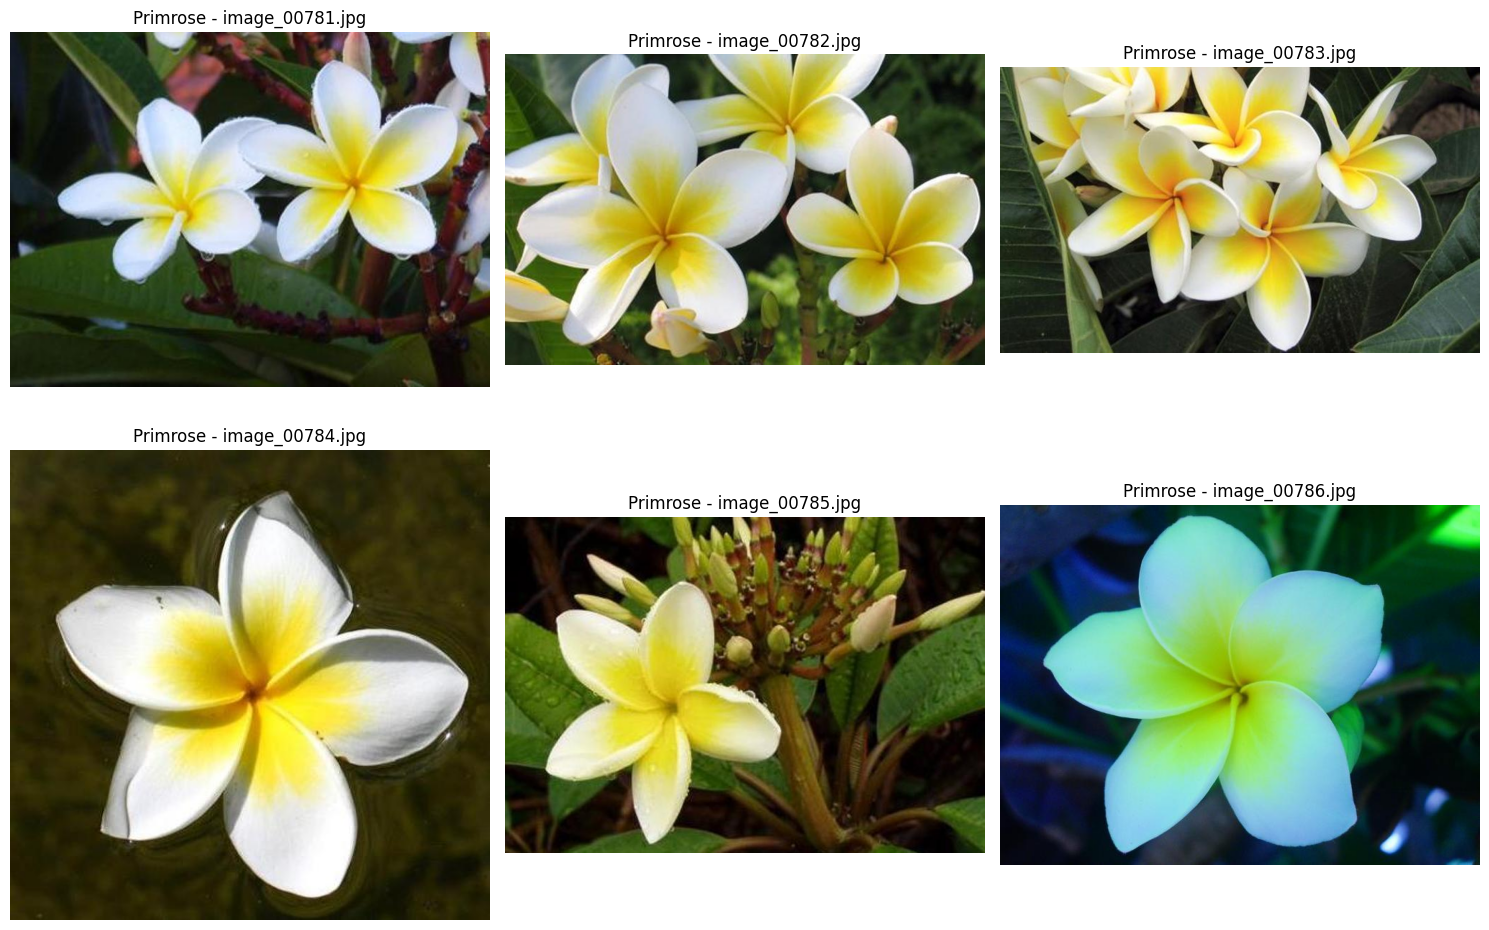

In [37]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

def find_and_display_primrose(data_path='data/flowers-102/'):
    # Load labels
    mat_data = scipy.io.loadmat(os.path.join(data_path, 'imagelabels.mat'))
    labels = mat_data['labels'][0]
    
    # Find primrose images (class 81)
    primrose_class = 81
    primrose_indices = np.where(labels == primrose_class)[0]
    
    # Look for image directory
    possible_image_dirs = ['jpg', 'images', '102flowers', 'flowers']
    image_dir = None
    
    for dir_name in possible_image_dirs:
        test_path = os.path.join(data_path, dir_name)
        if os.path.exists(test_path):
            image_dir = test_path
            break
    
    if image_dir is None:
        # Look for images in the main directory
        image_dir = data_path
    
    print(f"Looking for images in: {image_dir}")
    
    # Display first few primrose images
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    displayed = 0
    for i, idx in enumerate(primrose_indices[:6]):  # Show first 6
        img_num = idx + 1  # 1-indexed
        
        # Try different naming conventions
        possible_names = [
            f"image_{img_num:05d}.jpg",
            f"image_{img_num:04d}.jpg",
            f"{img_num:05d}.jpg",
            f"{img_num:04d}.jpg"
        ]
        
        image_path = None
        for name in possible_names:
            test_path = os.path.join(image_dir, name)
            if os.path.exists(test_path):
                image_path = test_path
                break
        
        if image_path and os.path.exists(image_path):
            img = Image.open(image_path)
            axes[displayed].imshow(img)
            axes[displayed].set_title(f"Primrose - {os.path.basename(image_path)}")
            axes[displayed].axis('off')
            displayed += 1
            print(f"Found: {image_path}")
    
    # Hide unused subplots
    for i in range(displayed, 6):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return primrose_indices

# Run the function
primrose_indices = find_and_display_primrose()


True label: pink primrose


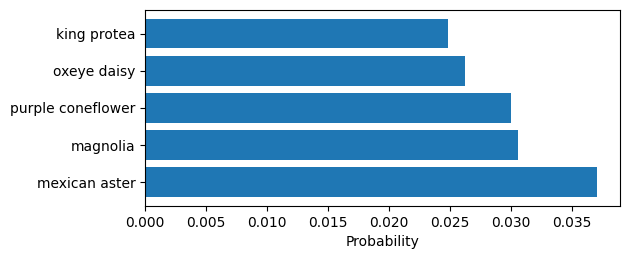

Top 5 predictions:
  mexican aster: 0.0371
  magnolia: 0.0306
  purple coneflower: 0.0300
  oxeye daisy: 0.0262
  king protea: 0.0248

True label: pink primrose


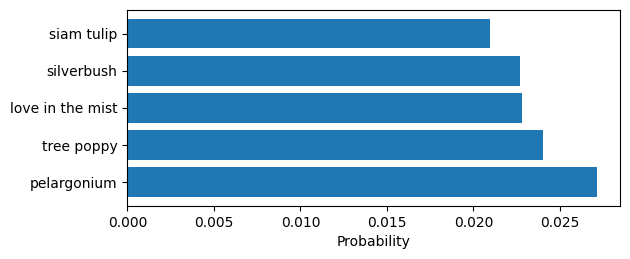

Top 5 predictions:
  pelargonium: 0.0271
  tree poppy: 0.0240
  love in the mist: 0.0228
  silverbush: 0.0227
  siam tulip: 0.0210

True label: pink primrose


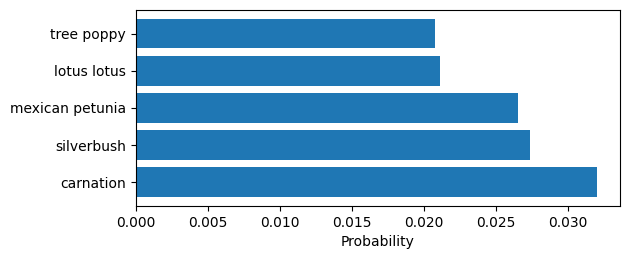

Top 5 predictions:
  carnation: 0.0320
  silverbush: 0.0274
  mexican petunia: 0.0266
  lotus lotus: 0.0212
  tree poppy: 0.0208


In [22]:
def predict_image(model, image_path=None, img_tensor=None):
    """Make a prediction on a single image"""
    model.eval()
    
    if image_path:
        # Load and preprocess the image
        img = Image.open(image_path).convert('RGB')
        img_tensor = data_transforms['test'](img).unsqueeze(0).to(device)
    elif img_tensor is not None:
        # Ensure the tensor has a batch dimension
        if img_tensor.dim() == 3:
            img_tensor = img_tensor.unsqueeze(0)
        img_tensor = img_tensor.to(device)
    else:
        raise ValueError("Either image_path or img_tensor must be provided")
    
    # Get predictions
    with torch.no_grad():
        outputs = model(img_tensor)
        _, preds = torch.max(outputs, 1)
        predicted_class = label_list[preds.item()]
        
        # Get probabilities
        probs = F.softmax(outputs, dim=1).squeeze().cpu().numpy()
        
    # Display the image and prediction
    if image_path:
        img = Image.open(image_path).convert('RGB')
        plt.figure(figsize=(6, 8))
        plt.subplot(2, 1, 1)
        plt.imshow(img)
        plt.title(f"Prediction: {predicted_class}")
        plt.axis('off')
    
    # Display top 5 predictions
    plt.subplot(2, 1, 2)
    top5_prob, top5_idx = torch.topk(F.softmax(outputs, dim=1), 5)
    top5_labels = [label_list[idx] for idx in top5_idx.squeeze().cpu().numpy()]
    top5_probs = top5_prob.squeeze().cpu().numpy()
    
    plt.barh(np.arange(5), top5_probs)
    plt.yticks(np.arange(5), top5_labels)
    plt.xlabel('Probability')
    plt.tight_layout()
    plt.show()
    
    return {
        "prediction": predicted_class,
        "confidence": float(top5_probs[0]),
        "top5": list(zip(top5_labels, top5_probs.tolist()))
    }

# Let's make predictions on some test images
test_loader_iter = iter(loaders['test'])
images, labels = next(test_loader_iter)

for i in range(3):  # Show predictions for 3 sample images
    img = images[i]
    true_label = label_list[labels[i]]
    
    print(f"\nTrue label: {true_label}")
    predictions = predict_image(learner.model, img_tensor=img)
    
    print(f"Top 5 predictions:")
    for flower, prob in predictions["top5"]:
        print(f"  {flower}: {prob:.4f}")

## 12. Transfer Learning

Let's create a simple function to process and classify images from external sources:

In [38]:
class TransferLearningModel(nn.Module):
    def __init__(self, num_classes=102):
        super(TransferLearningModel, self).__init__()
        # Load pre-trained ResNet-50 model
        self.model = torchvision.models.resnet50(pretrained=True)
        
        # Freeze early layers
        for param in list(self.model.parameters())[:-20]:
            param.requires_grad = False
            
        # Replace final fully connected layer
        num_features = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        
        self.labels = label_list
        
    def forward(self, x):
        return self.model(x)
        
    def predictions(self, x):
        """Generate predictions with probabilities for each class"""
        with torch.no_grad():
            logits = self.forward(x)
            probs = torch.nn.functional.softmax(logits, dim=1)
            
            # For a single image
            if x.dim() == 3:
                x = x.unsqueeze(0)  # Add batch dimension
                predictions = dict(zip(self.labels, probs.cpu().detach().numpy().flatten()))
            # For a batch of images
            else:
                # Return prediction for each image in batch
                predictions = [dict(zip(self.labels, p)) for p in probs.cpu().detach().numpy()]
                
        return predictions

# Initialize the transfer learning model
transfer_model = TransferLearningModel().to(device)

# Create configuration for transfer learning model
transfer_config = LearnerConfig(
    model=transfer_model,
    criterion=nn.CrossEntropyLoss(),
    epochs=1,
    batch_size=32,
    lr=0.0001,
    device=device,
)

# Create learner and train the model
transfer_learner = Learner(transfer_config, loaders)
transfer_history, transfer_metrics = transfer_learner.fit()

# Plot training history
transfer_learner.plot_training_history()

# Print overall metrics
print("\nTransfer Learning Model Performance:")
print("----------------------------------")
for metric, value in transfer_metrics["overall_metrics"].items():
    print(f"{metric.capitalize()}: {value:.4f}")

# Export the trained transfer learning model
transfer_learner.export('flower_classifier_transfer.pt')

/Users/puriaizady/Code/mastering-generative-ai/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/puriaizady/Code/mastering-generative-ai/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch	Train Loss	Val Loss	Accuracy
-----	----------	--------	--------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [39]:
def transfer_model_inference(image_path):
    """
    Classify a flower image from a file path
    
    Args:
        image_path: Path to the image file
        model_path: Path to the saved model
        
    Returns:
        Dictionary with prediction and confidence scores
    """
    # Load the model
    model = transfer_learner.model
    model.eval()
        
    # Load and preprocess the image
    try:
        img = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f"Could not open image at {image_path}. Error: {e}")
        return None
    
    # Apply transformations
    transform = data_transforms['test']
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    # Make prediction
    model.to(device)  # Ensure model is on correct device
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = F.softmax(outputs, dim=1).squeeze().cpu().numpy()
        
    # Get top 5 predictions
    top5_idx = np.argsort(probs)[-5:][::-1]
    top5_probs = probs[top5_idx]
    top5_labels = [label_list[i] for i in top5_idx]
    
    # Display results
    plt.figure(figsize=(10, 5))
    
    # Show image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Prediction: {top5_labels[0]}\nConfidence: {top5_probs[0]:.2f}")
    plt.axis('off')
    
    # Show top 5 predictions
    plt.subplot(1, 2, 2)
    plt.barh(np.arange(5), top5_probs)
    plt.yticks(np.arange(5), top5_labels)
    plt.xlabel('Probability')
    plt.title('Top 5 Predictions')
    plt.tight_layout()
    plt.show()
    
    return {
        "prediction": top5_labels[0],
        "confidence": float(top5_probs[0]),
        "top5": list(zip(top5_labels, top5_probs.tolist()))
    }

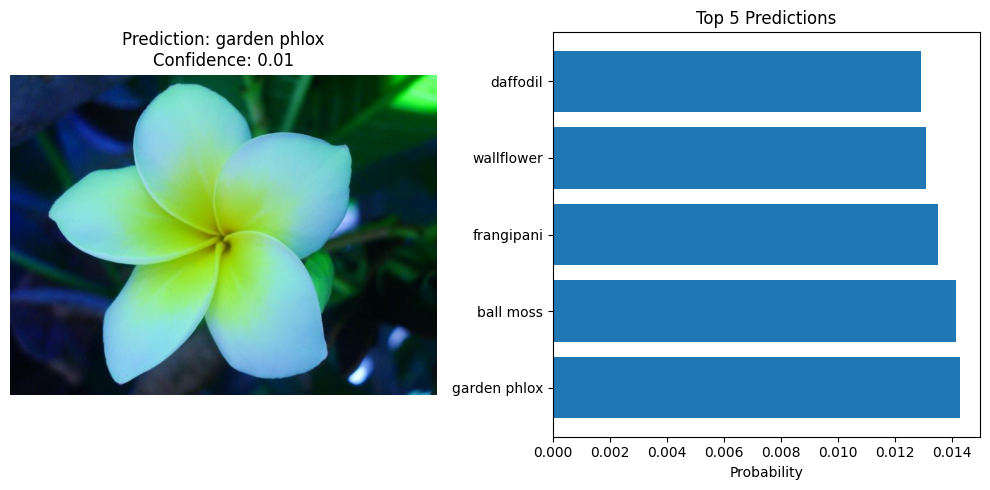

{'prediction': 'garden phlox',
 'confidence': 0.014279852621257305,
 'top5': [('garden phlox', 0.014279852621257305),
  ('ball moss', 0.014149840921163559),
  ('frangipani', 0.013532659970223904),
  ('wallflower', 0.013100292533636093),
  ('daffodil', 0.01291859894990921)]}

In [40]:
transfer_model_inference("data/flowers-102/jpg/image_00786.jpg")

## Conclusion and Next Steps

In this lab, we've explored:

1. Building a neural network from scratch with custom components
2. Loading and preprocessing the Oxford Flowers 102 dataset
3. Training and evaluating image classification models
4. Using transfer learning to improve performance


### Additional Resources:

- [PyTorch Documentation](https://pytorch.org/docs/stable/index.html)
- [Oxford Flowers 102 Dataset Paper](https://www.robots.ox.ac.uk/~vgg/data/flowers/102/index.html)
